In [1]:
import itertools as it

import boto3
import botocore
from IPython.core.display import display
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp


Matplotlib is building the font cache; this may take a moment.


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmfxdz0
interpreter: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
notebook name: 2025-11-25-external-selfbb-timeshift
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-25-external-selfbb-timeshift.ipynb
revision: bdac574
timestamp: 2025-11-25T19:57:26Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-11-25-external-timeshift"


In [5]:
df_all = []
for what, prefix in [
    ("nobb", "endeavor=16/external-competitions/stage=2+what=collated/"),
    ("selfbb", "endeavor=16/external-competitions-focalbb/stage=2+what=collated/"),
    ("selfbb33", "endeavor=16/external-competitions-bg33-focalbb/stage=2+what=collated/"),
    ("selfbb40", "endeavor=16/external-competitions-bg40-focalbb/stage=2+what=collated/"),
    ("selfbb50", "endeavor=16/external-competitions-bg50-focalbb/stage=2+what=collated/"),
    ("selfbb66", "endeavor=16/external-competitions-bg66-focalbb/stage=2+what=collated/"),
    ("selfbb75", "endeavor=16/external-competitions-bg75-focalbb/stage=2+what=collated/"),
    ("truebb", "endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/"),
    ("selfbb90", "endeavor=16/external-competitions-bg90-focalbb/stage=2+what=collated/"),
    ("selfbb99", "endeavor=16/external-competitions-bg99-focalbb/stage=2+what=collated/"),
]:
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket("prq49")


    competitions = bucket_handle.objects.filter(Prefix=prefix)
    dfs = [
        pd.read_csv(
          f's3://prq49/{competitions.key}',
        )
        for competitions in competitions
    ]
    print(len(dfs))
    df = pd.concat(dfs, ignore_index=True)
    df["kind"] = what

    df_all.append(df)

df = pd.concat(df_all, ignore_index=True)


100
100
20
20
20
20
20
99
20
20


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
169217    0.000000
169220    0.000000
169223    0.929577
169225    0.147200
169228    1.000000
Name: Focal Prevalence, Length: 61157, dtype: float64

teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


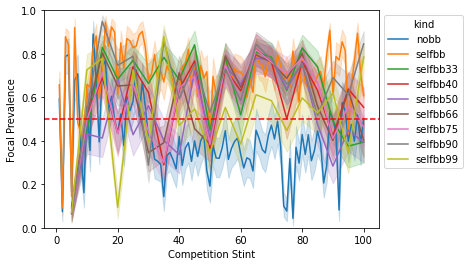

In [6]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

with tp.teed(
    sns.lineplot,
    data=dfx[
        dfx["kind"] != "truebb"
    ],
    x="Competition Stint",
    y="Focal Prevalence",
    hue="kind",
    teeplot_subdir=teeplot_subdir,
) as ax:
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.axhline(y=0.5, color='r', linestyle='--')
    plt.ylim(0, 1)


Focal Prevalence
Competition Stint kind                      
1                 nobb              0.592569
                  selfbb            0.657924
2                 nobb              0.074193
                  selfbb            0.091512
                  truebb            0.029403
...                                      ...
100               selfbb66          0.403701
                  selfbb75          0.463988
                  selfbb90          0.845886
                  selfbb99          0.785467
                  truebb            0.530372

[439 rows x 1 columns]

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendsquare+viz=imshow+ext=.png


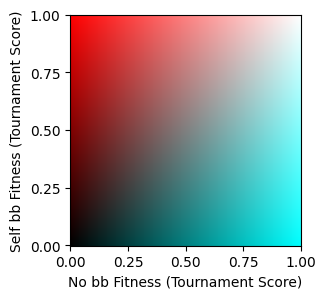

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+type=legendband+viz=imshow+ext=.png


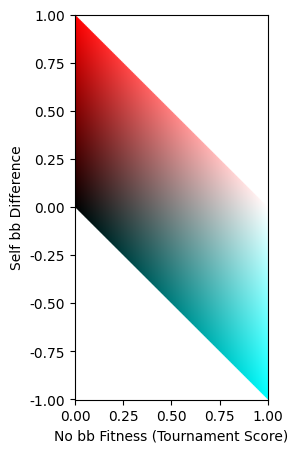

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=square+viz=imshow+ext=.png


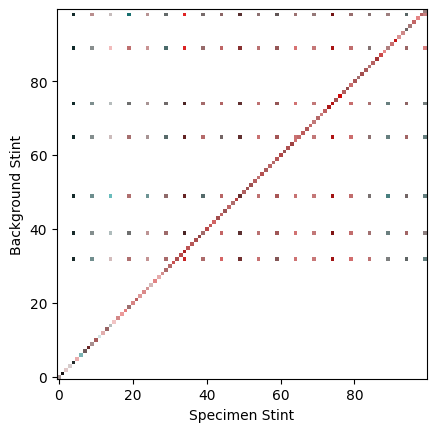

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=sub+type=square+viz=imshow+ext=.png


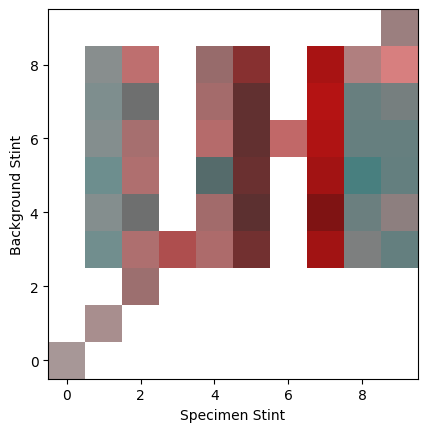

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0+slice=all+type=band+viz=imshow+ext=.png


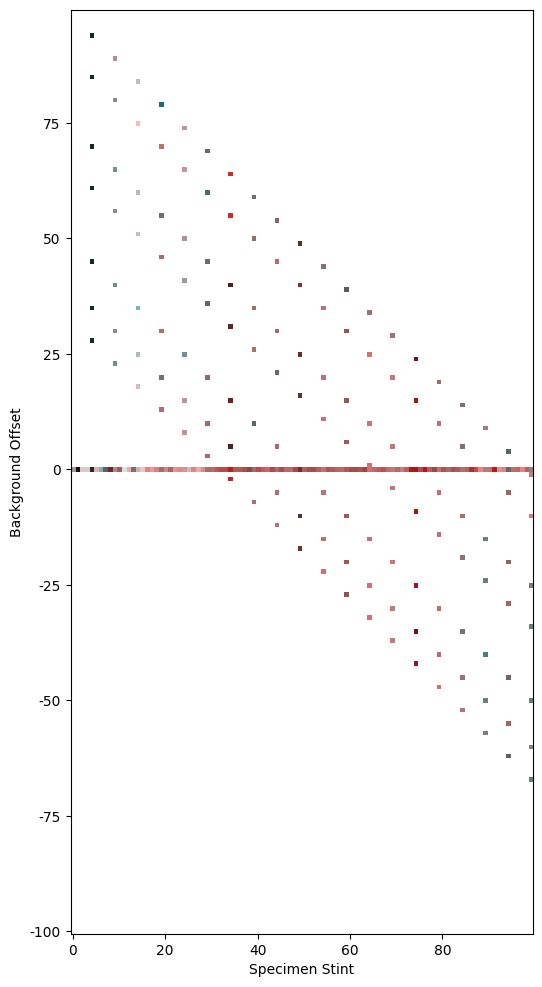

teeplots/2025-11-25-external-timeshift/palette=0+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=0+slice=sub+type=band+viz=imshow+ext=.png


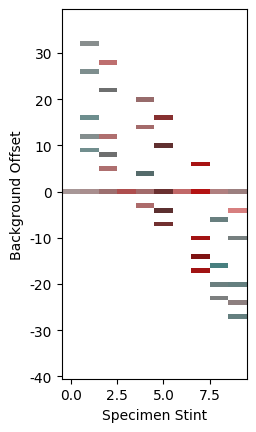

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendsquare+viz=imshow+ext=.png


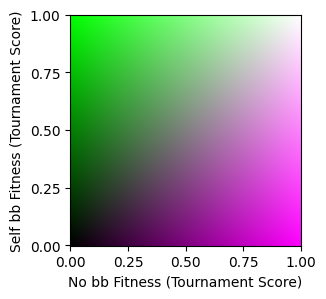

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+type=legendband+viz=imshow+ext=.png


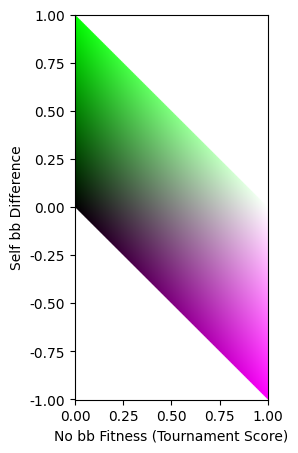

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=square+viz=imshow+ext=.png


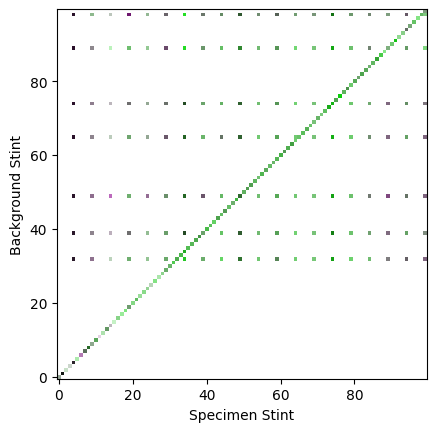

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=sub+type=square+viz=imshow+ext=.png


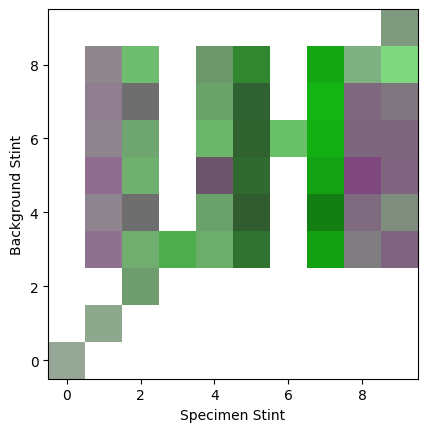

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1+slice=all+type=band+viz=imshow+ext=.png


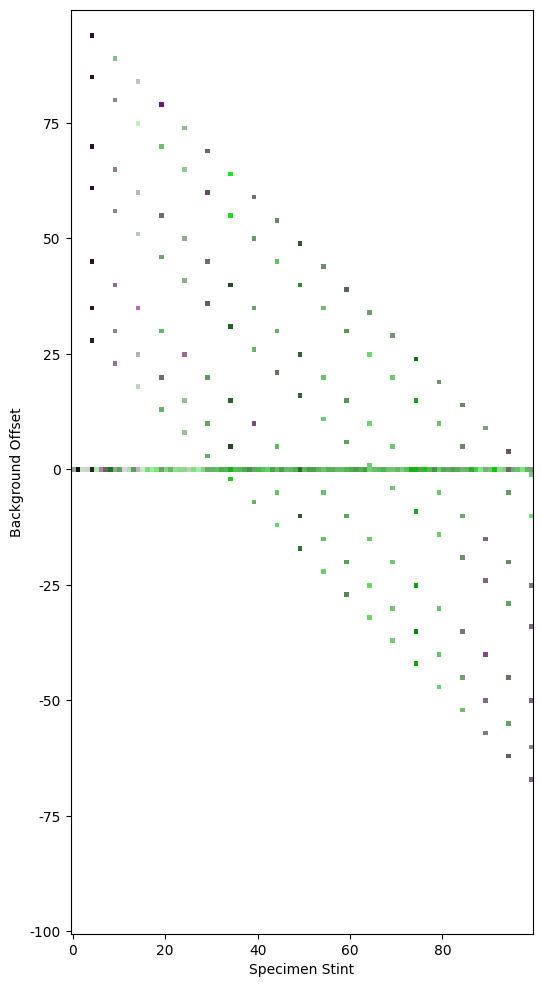

teeplots/2025-11-25-external-timeshift/palette=1+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=1+slice=sub+type=band+viz=imshow+ext=.png


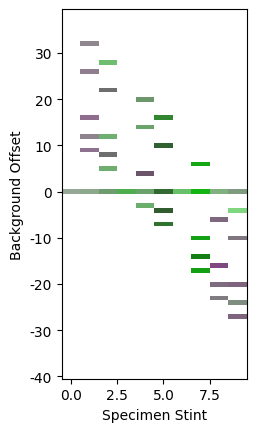

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendsquare+viz=imshow+ext=.png


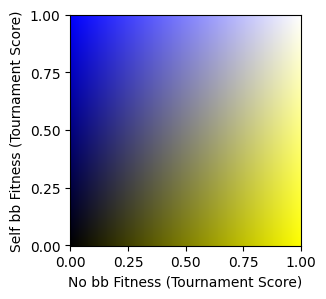

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+type=legendband+viz=imshow+ext=.png


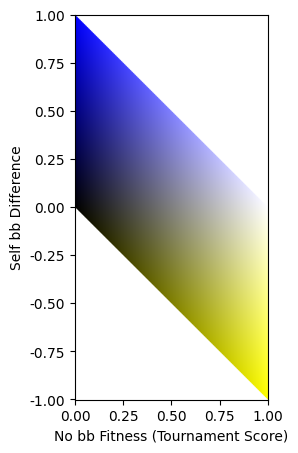

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=square+viz=imshow+ext=.png


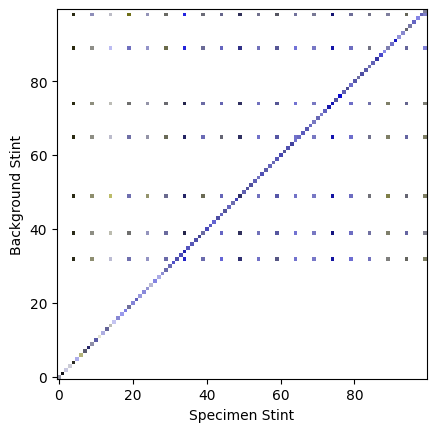

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=sub+type=square+viz=imshow+ext=.png


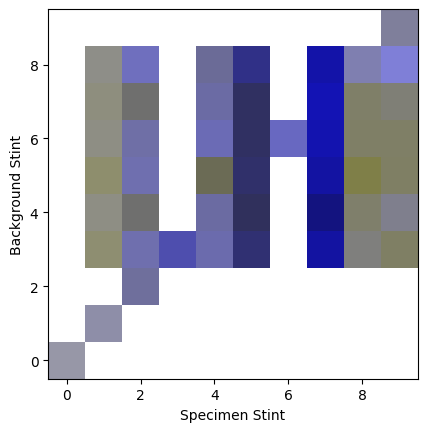

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2+slice=all+type=band+viz=imshow+ext=.png


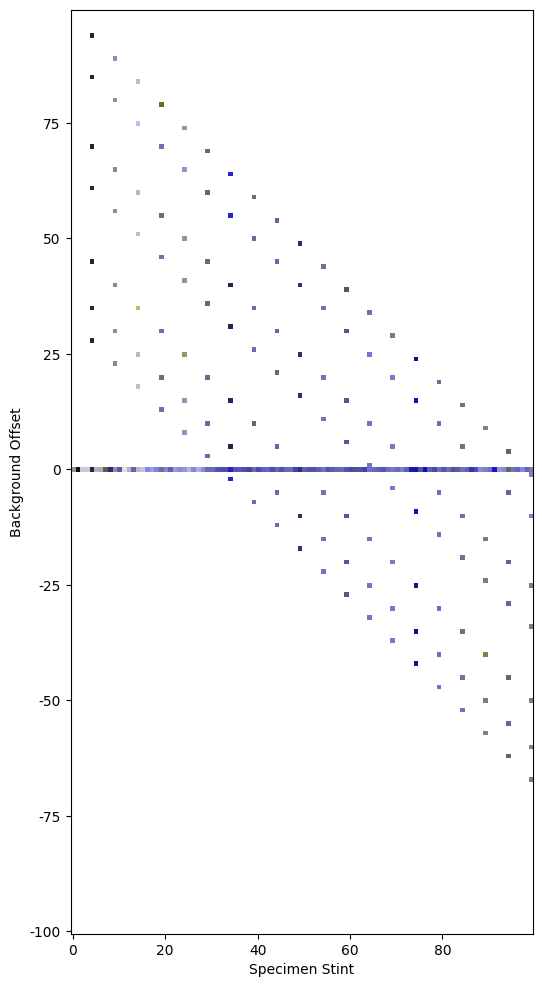

teeplots/2025-11-25-external-timeshift/palette=2+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=2+slice=sub+type=band+viz=imshow+ext=.png


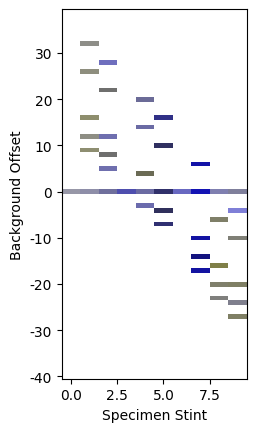

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendsquare+viz=imshow+ext=.png


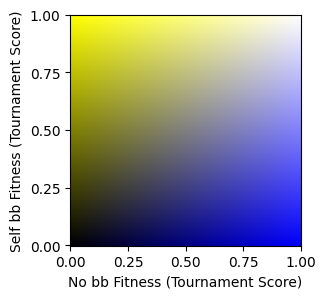

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+type=legendband+viz=imshow+ext=.png


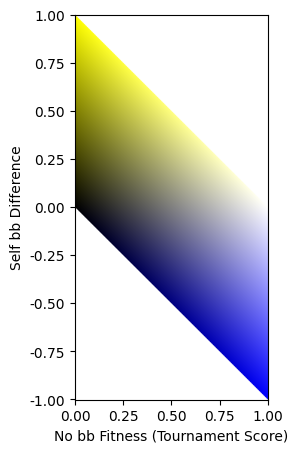

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=square+viz=imshow+ext=.png


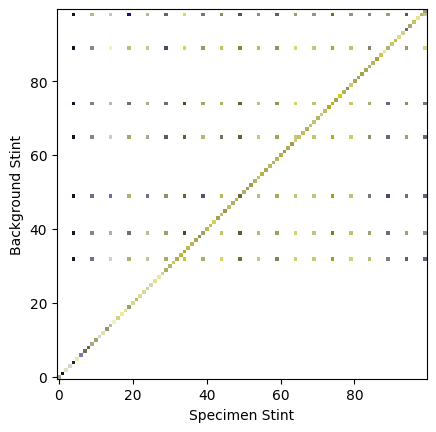

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=sub+type=square+viz=imshow+ext=.png


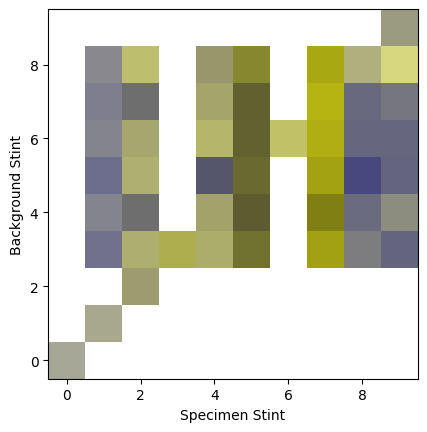

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~1+slice=all+type=band+viz=imshow+ext=.png


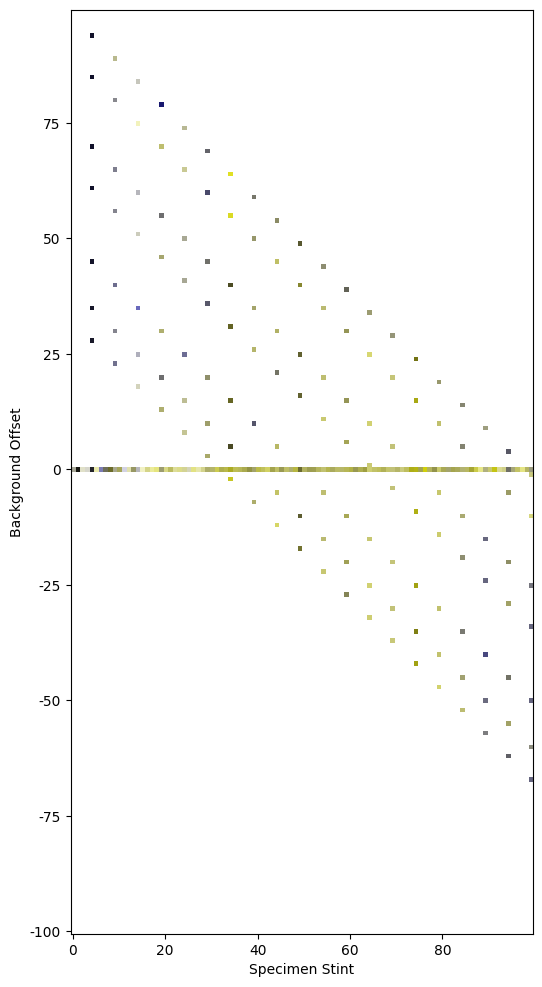

teeplots/2025-11-25-external-timeshift/palette=0~1+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=0~1+slice=sub+type=band+viz=imshow+ext=.png


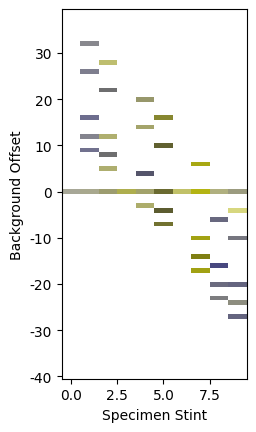

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendsquare+viz=imshow+ext=.png


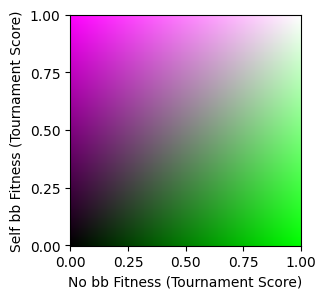

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+type=legendband+viz=imshow+ext=.png


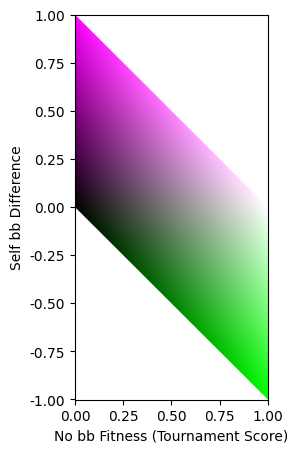

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=square+viz=imshow+ext=.png


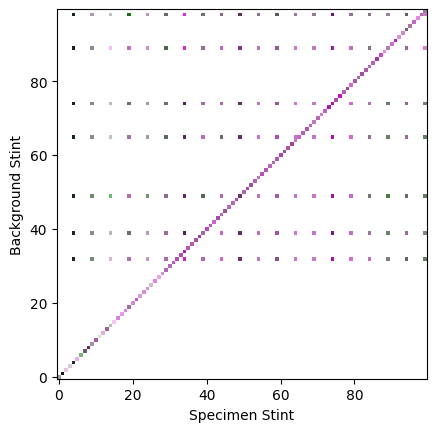

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=sub+type=square+viz=imshow+ext=.png


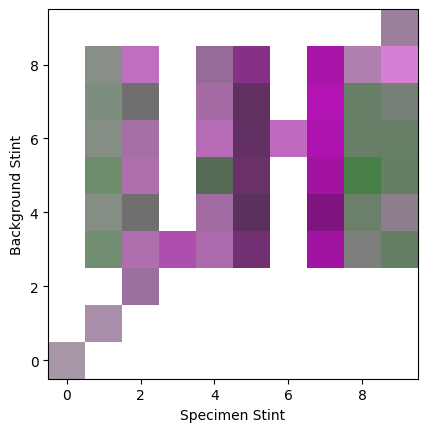

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=0~2+slice=all+type=band+viz=imshow+ext=.png


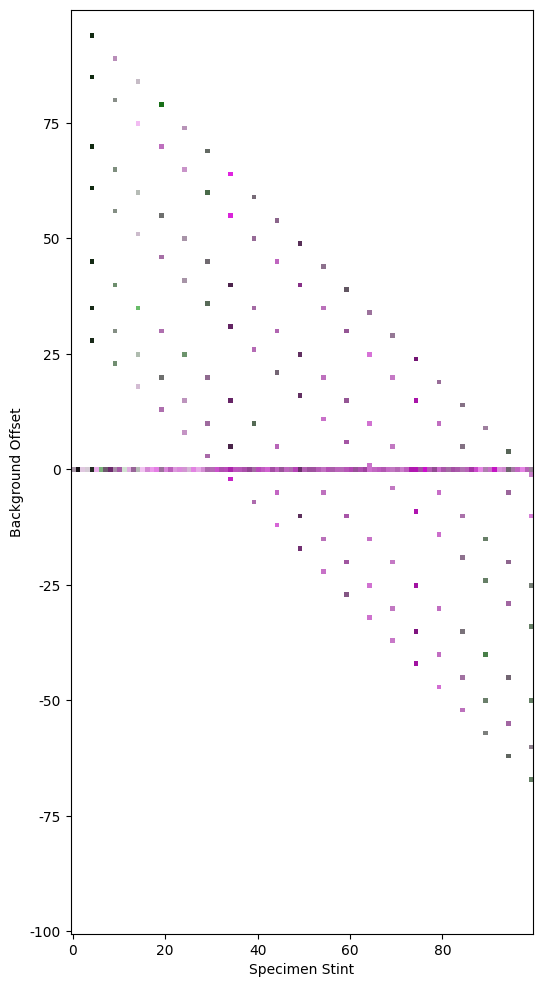

teeplots/2025-11-25-external-timeshift/palette=0~2+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=0~2+slice=sub+type=band+viz=imshow+ext=.png


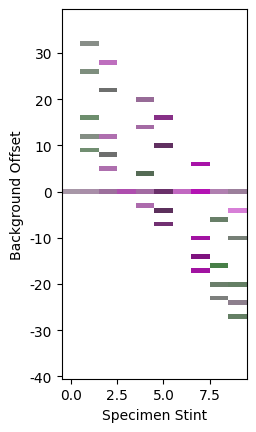

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendsquare+viz=imshow+ext=.png


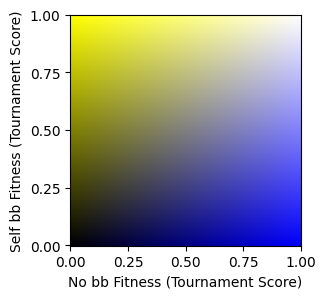

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+type=legendband+viz=imshow+ext=.png


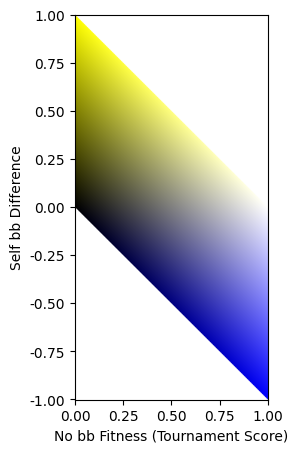

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=square+viz=imshow+ext=.png


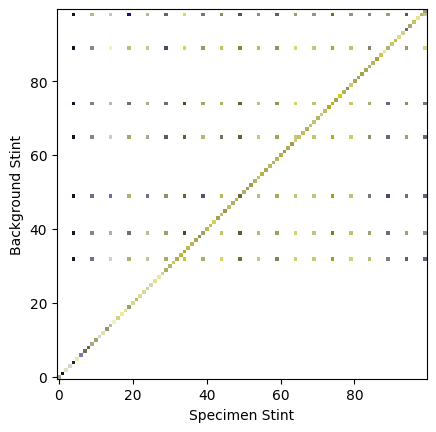

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=sub+type=square+viz=imshow+ext=.png


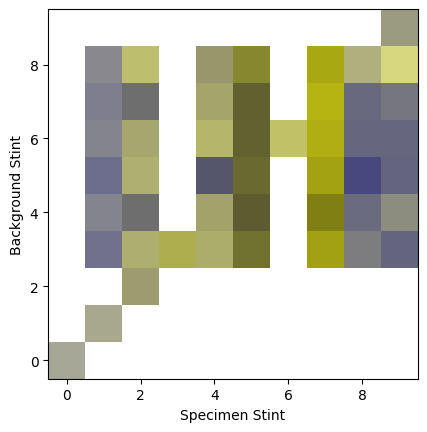

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~0+slice=all+type=band+viz=imshow+ext=.png


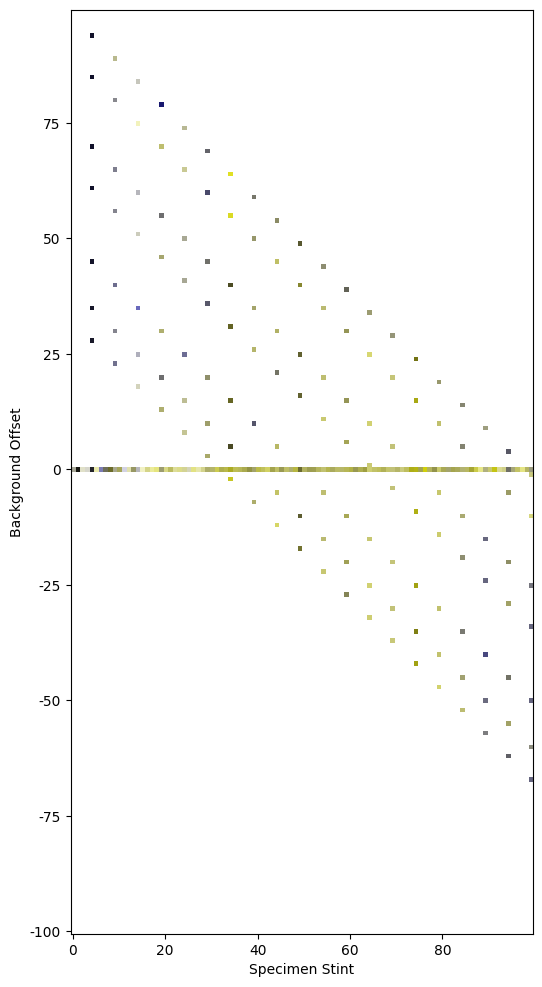

teeplots/2025-11-25-external-timeshift/palette=1~0+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=1~0+slice=sub+type=band+viz=imshow+ext=.png


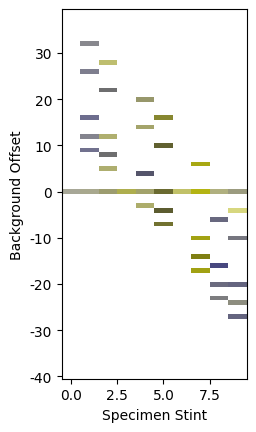

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendsquare+viz=imshow+ext=.png


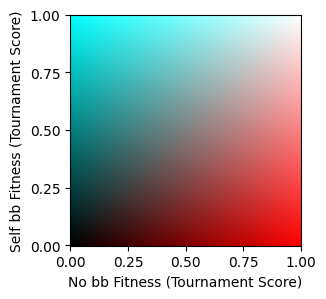

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+type=legendband+viz=imshow+ext=.png


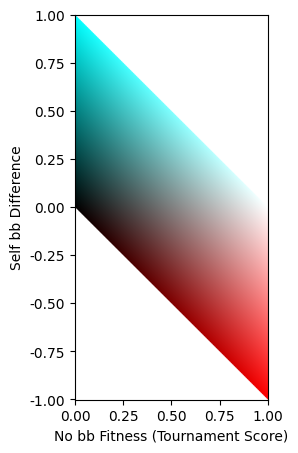

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=square+viz=imshow+ext=.png


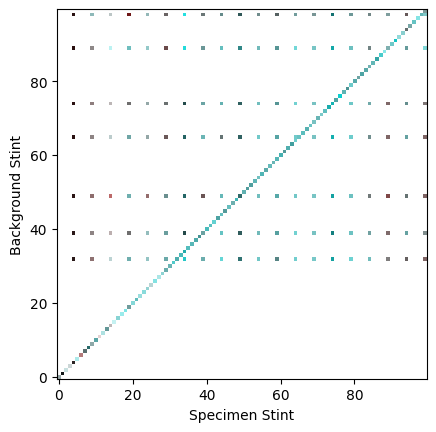

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=sub+type=square+viz=imshow+ext=.png


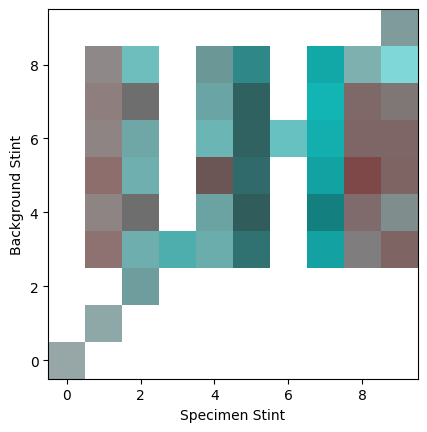

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=1~2+slice=all+type=band+viz=imshow+ext=.png


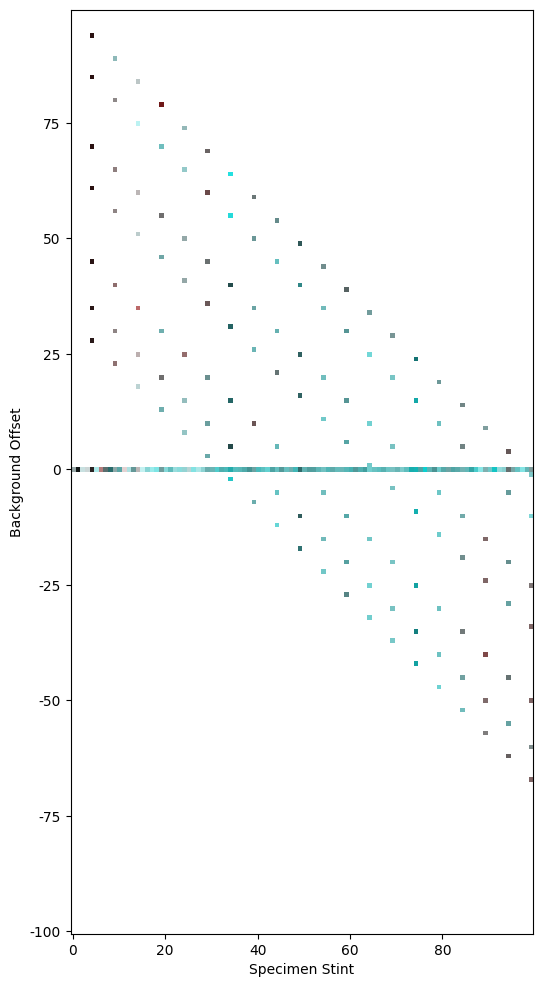

teeplots/2025-11-25-external-timeshift/palette=1~2+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=1~2+slice=sub+type=band+viz=imshow+ext=.png


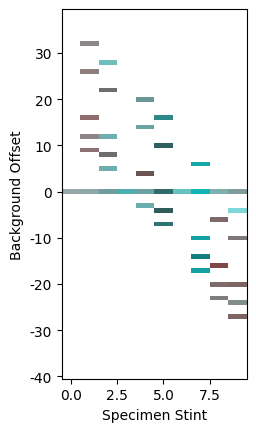

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendsquare+viz=imshow+ext=.png


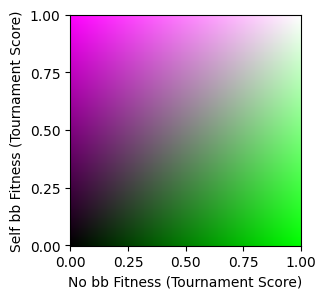

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+type=legendband+viz=imshow+ext=.png


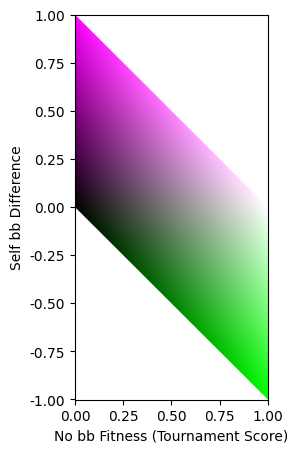

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=square+viz=imshow+ext=.png


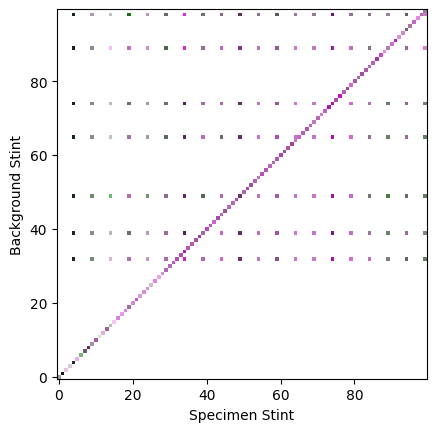

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=sub+type=square+viz=imshow+ext=.png


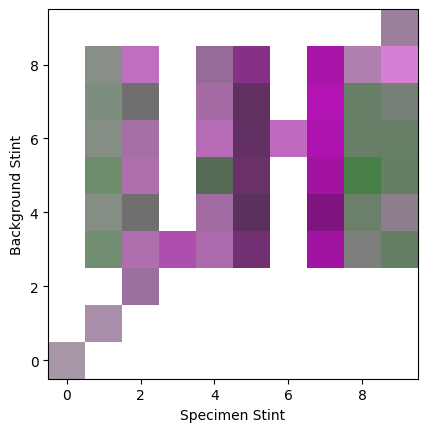

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~0+slice=all+type=band+viz=imshow+ext=.png


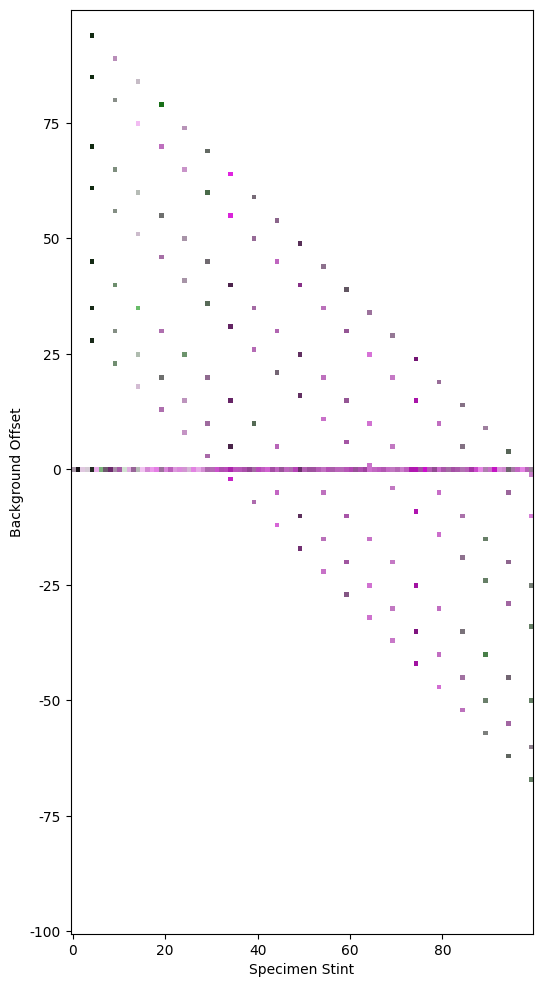

teeplots/2025-11-25-external-timeshift/palette=2~0+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=2~0+slice=sub+type=band+viz=imshow+ext=.png


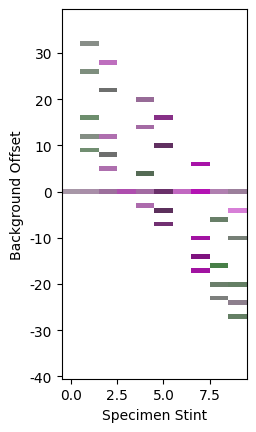

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendsquare+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendsquare+viz=imshow+ext=.png


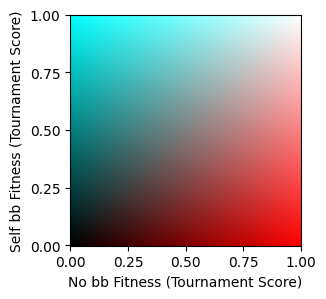

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendband+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+type=legendband+viz=imshow+ext=.png


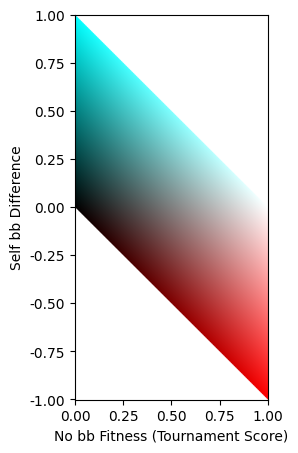

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=square+viz=imshow+ext=.png


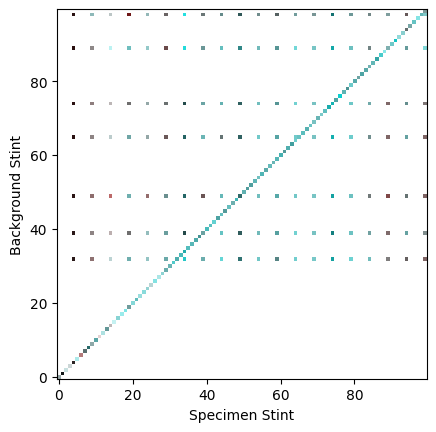

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=sub+type=square+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=sub+type=square+viz=imshow+ext=.png


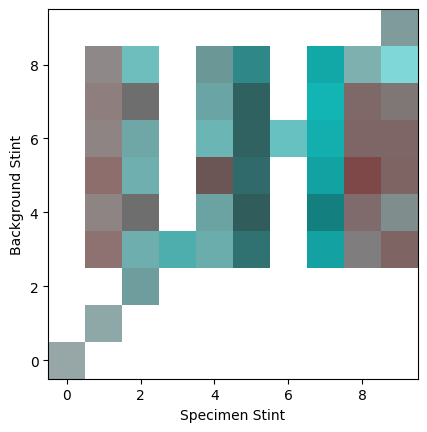

teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/aspect=equal+palette=2~1+slice=all+type=band+viz=imshow+ext=.png


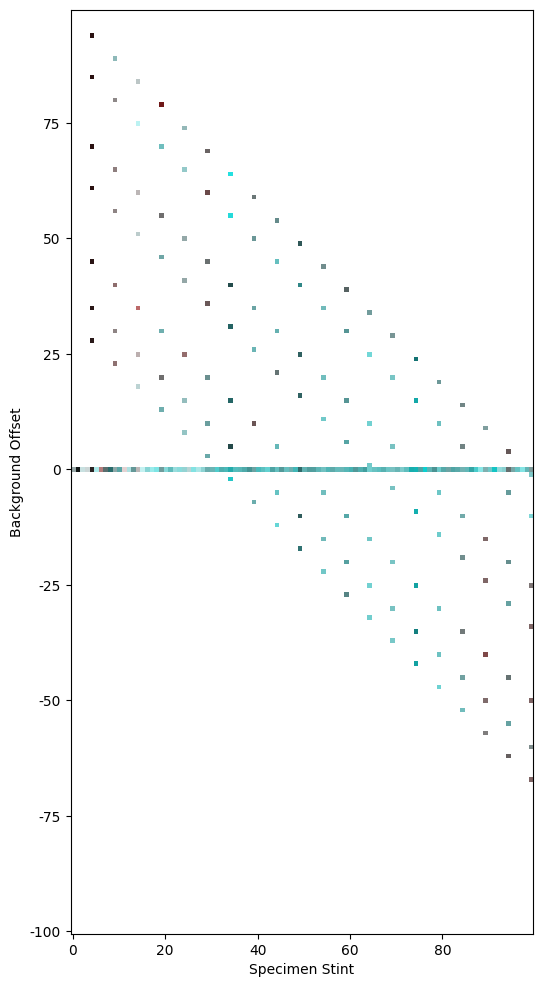

teeplots/2025-11-25-external-timeshift/palette=2~1+slice=sub+type=band+viz=imshow+ext=.pdf
teeplots/2025-11-25-external-timeshift/palette=2~1+slice=sub+type=band+viz=imshow+ext=.png


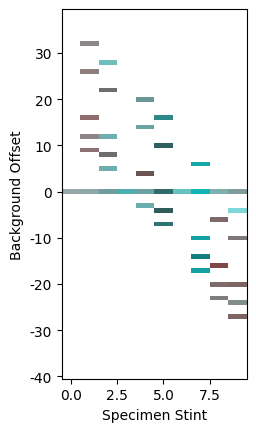

In [7]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
].groupby(["Competition Stint", "kind"]).mean()
display(dfx)

bb_matrix = np.full((100, 100), np.nan)
for stint in range(1, 101):
    bb_matrix[stint - 1, stint - 1] = dfx.loc[
        (stint, "selfbb")
    ].item()

for comp in 33, 40, 50, 66, 75, 90, 99:
    for stint in range(1, 101):
        try:
            bb_matrix[comp - 1, stint - 1] = dfx.loc[
                (stint, f"selfbb{comp}")
            ].item()
        except KeyError:
            pass


nobb_matrix = np.array(
    [
        [
            dfx.loc[(stint, "nobb")].item()
            for stint in range(1, 101)
        ]
        for __ in range(1, 101)
    ],
)

def imshow(data, **kwargs):
    # force NaN handling, because some render backends show black vs white
    nan = 1 if np.issubdtype(data.dtype, np.integer) else 1.0
    data = data.copy()
    mask = np.isnan(data).any(axis=-1)
    data[mask] = np.nan
    return plt.imshow(
        np.nan_to_num(data, nan=nan),
        **kwargs,
    )

for rgb_bb in it.chain(
    it.permutations(range(3), r=1),
    it.permutations(range(3), r=2),
):
    palette = "~".join(map(str, rgb_bb))

    legend_matrix_nobb, legend_matrix_bb = np.meshgrid(
        np.linspace(0, 1, 256),
        np.linspace(0, 1, 256),
    )
    legend_rgb_matrix = np.zeros((256, 256, 3), dtype=float)
    legend_rgb_matrix[:, :, 0], legend_rgb_matrix[:, :, 1], legend_rgb_matrix[:, :, 2] = (
        legend_matrix_nobb, legend_matrix_nobb, legend_matrix_nobb
    )
    for v in rgb_bb:
        legend_rgb_matrix[:, :, v] = legend_matrix_bb

    with tp.teed(
        imshow,
        legend_rgb_matrix,
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "legendsquare", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        aximg.figure.set_size_inches(3, 3)
        ax.set_xlabel("No bb Fitness (Tournament Score)")
        ax.set_ylabel("Self bb Fitness (Tournament Score)")
        ax.set_xticks([0, 64, 128, 192, 256])
        ax.set_yticks([0, 64, 128, 192, 256])
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{val/256:.2f}",
            ),
        )
        ax.xaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{val/256:.2f}",
            ),
        )
        ax.invert_yaxis()

    legend_reshaped = np.full((512, 256, 3), np.nan)
    for i, j in it.product(range(256), range(256)):
        legend_reshaped[i + 256 - j, j, :] = legend_rgb_matrix[i, j, :]

    with tp.teed(
        imshow,
        legend_reshaped,
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "legendband", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        aximg.figure.set_size_inches(3, 5)
        ax.set_xlabel("No bb Fitness (Tournament Score)")
        ax.set_ylabel("Self bb Difference")
        ax.set_xticks([0, 64, 128, 192, 256])
        ax.set_yticks([0, 64, 128, 192, 256, 320, 384, 448, 512])
        ax.xaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{val/256:.2f}",
            ),
        )
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{(val - 256)/256:.2f}",
            ),
        )
        ax.invert_yaxis()

    rgb_matrix = np.zeros((100, 100, 3), dtype=float)
    rgb_matrix[:, :, 0], rgb_matrix[:, :, 1], rgb_matrix[:, :, 2] = (
        nobb_matrix, nobb_matrix, nobb_matrix
    )
    for v in rgb_bb:
        rgb_matrix[:, :, v] = bb_matrix



    with tp.teed(
        imshow,
        rgb_matrix,
        aspect="equal",
        teeplot_outattrs={"type": "square", "slice": "all", "palette": palette},
        teeplot_subdir=teeplot_subdir,
    ) as aximg:
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Stint")
        ax.invert_yaxis()

    subslice = np.array([1, 10, 20, 33, 40, 50, 66, 75, 90, 100]) - 1

    with tp.teed(
        imshow,
        rgb_matrix[
            subslice, :, :
        ][
            :,subslice, :
        ],
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "square", "slice": "sub", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Stint")
        ax.invert_yaxis()

    reshaped = np.full((200, 100, 3), np.nan)
    for i, j in it.product(range(100), range(100)):
        reshaped[i + 100 - j, j, :] = rgb_matrix[i, j, :]

    assert (~np.isnan(reshaped)).sum() == (~np.isnan(rgb_matrix)).sum()

    with tp.teed(
        imshow,
        reshaped,
        aspect="equal",
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "band", "slice": "all", "palette": palette},
    ) as aximg:
        aximg.figure.set_size_inches(6, 12)
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Offset")
        ax.invert_yaxis()
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{int(val) - 100}",
            ),
        )

    with tp.teed(
        imshow,
        reshaped[
            np.array(
                [
                    [i, i + 3, i + 5, i + 8]
                    for i in range(0, 200, 10)
                ]
            ).flatten(),
            :,
            :,
        ][
            :, subslice, :
        ],
        aspect=0.25,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={"type": "band", "slice": "sub", "palette": palette},
    ) as aximg:
        ax = aximg.figure.gca()
        ax.set_xlabel("Specimen Stint")
        ax.set_ylabel("Background Offset")
        ax.invert_yaxis()
        ax.yaxis.set_major_formatter(
            mpl_ticker.FuncFormatter(
                lambda val, pos: f"{int(val) - 40}",
            ),
        )


0         1.000000
2         0.247078
4         0.006954
6         0.393959
8         0.299972
            ...   
169217    0.000000
169220    0.000000
169223    0.929577
169225    0.147200
169228    1.000000
Name: Focal Prevalence, Length: 61157, dtype: float64

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


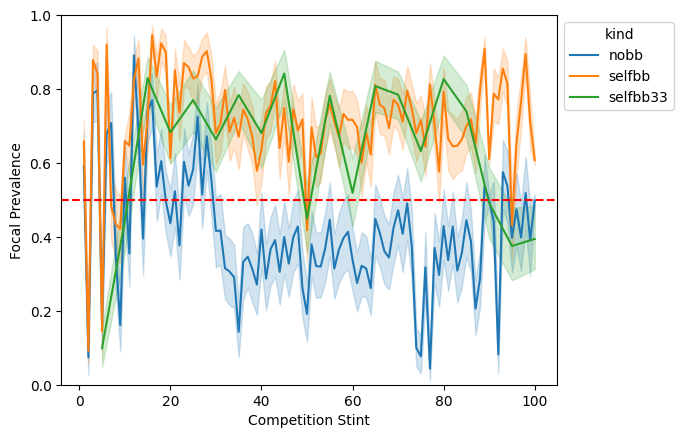

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


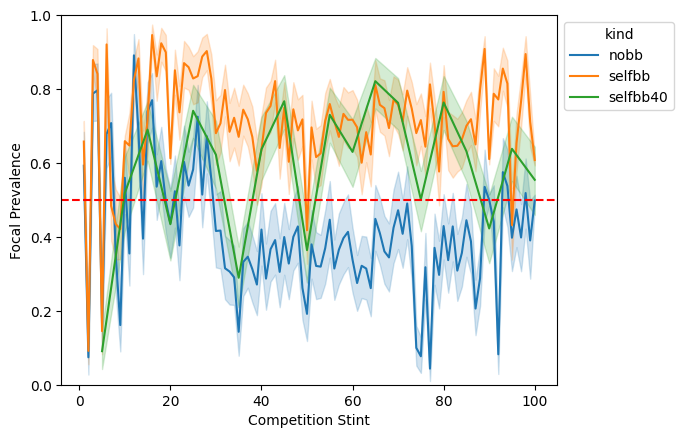

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


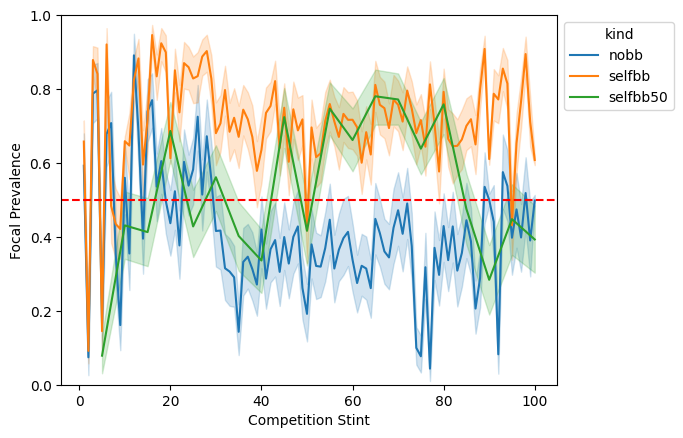

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


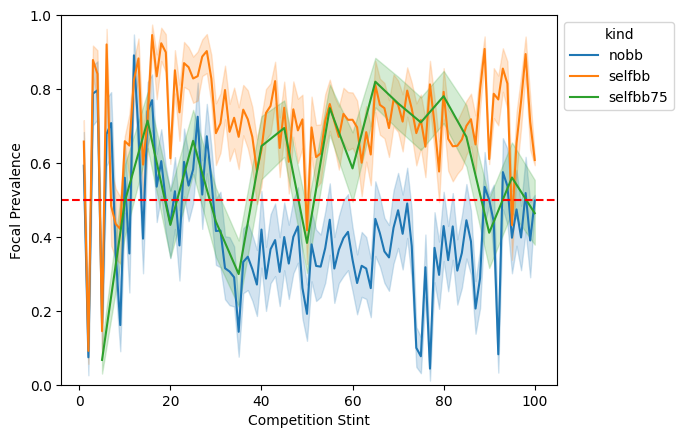

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


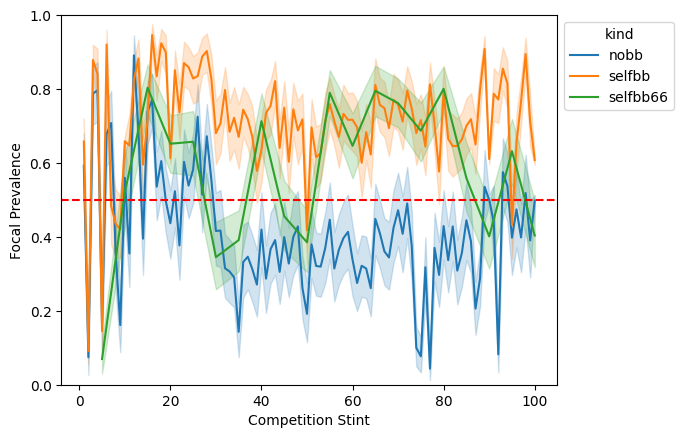

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


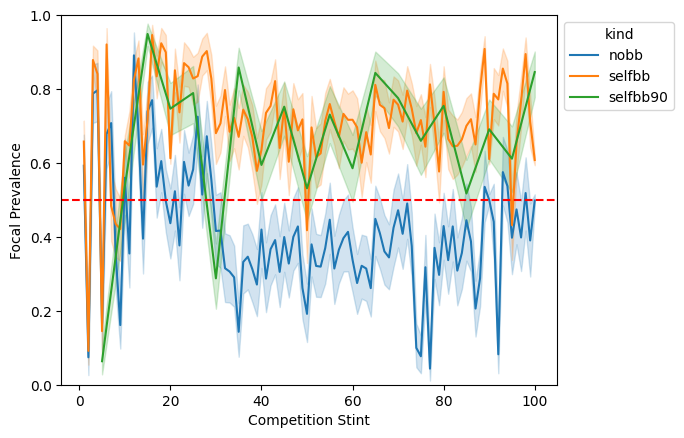

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png, overwriting it
  warnings.warn(


teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-11-25-external-timeshift/hue=kind+viz=lineplot+x=competition-stint+y=focal-prevalence+ext=.png


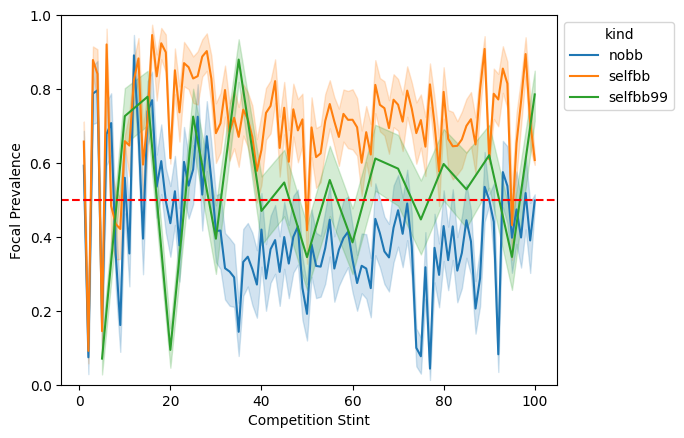

In [8]:
dfx = df.loc[
    (df["Root ID"] == 0),
    ["Competition Stint", "Focal Prevalence", "kind"]
]
display(dfx["Focal Prevalence"])

for kind in [
    "selfbb33",
    "selfbb40",
    "selfbb50",
    "selfbb75",
    "selfbb66",
    "selfbb90",
    "selfbb99",
]:
    with tp.teed(
        sns.lineplot,
        data=dfx[
            dfx["kind"].isin(["nobb", kind, "selfbb"])
        ],
        x="Competition Stint",
        y="Focal Prevalence",
        hue="kind",
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

        plt.axhline(y=0.5, color='r', linestyle='--')
        plt.ylim(0, 1)
